In [ ]:
from google.colab import drive
import os

# 1. Ngắt kết nối Drive hiện tại (nếu có)
drive.flush_and_unmount()

# 2. Xóa sạch thư mục mount cũ để đảm bảo không bị lỗi "Already contains files"
!rm -rf /content/drive

# 3. Kết nối lại
drive.mount('/content/drive')

# 4. Kiểm tra lại đường dẫn
os.chdir('/content/drive/MyDrive/PROJECT')
print("Đã kết nối lại thành công tới:", os.getcwd())

shell-init: error retrieving current directory: getcwd: cannot access parent directories: Transport endpoint is not connected
Mounted at /content/drive
Đã kết nối lại thành công tới: /content/drive/MyDrive/PROJECT


# Notebook 03 — Lexical Baselines and FP-Max Feature Enrichment

Notebook này xây dựng các mô hình gom cụm dựa trên đặc trưng lexical cho văn bản báo chí tiếng Việt.

Notebook gồm hai phần chính:

1. **Lexical baselines**
   - TF-IDF + SVD + KMeans
   - BM25 + SVD + KMeans

2. **FP-Max Feature Enrichment**
   - Tạo transaction nhị phân từ `lexical_text` bằng `CountVectorizer(binary=True)`
   - Khai thác maximal frequent patterns bằng FP-Max
   - Chuyển patterns thành binary features
   - Ghép TF-IDF với FP-Max features có trọng số `alpha`
   - Chạy KMeans lại để kiểm tra FP-Max có cải thiện hoặc hỗ trợ diễn giải cho baseline lexical hay không

Lưu ý phương pháp:

- FP-Max không chạy trên MiniLM embedding.
- FP-Max chỉ chạy trên transaction nhị phân tạo từ `lexical_text`.
- Notebook này kiểm tra tác động của FP-Max trên nhánh lexical.
- Pattern và feature FP-Max được lưu lại để sử dụng tiếp ở Notebook 05: MiniLM + FP-Max controlled hybrid.

In [ ]:
# Cell 2: Import thư viện
import pandas as pd
import numpy as np
import time
import json
import warnings
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import scipy.sparse as sp

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.metrics import (
    normalized_mutual_info_score,
    adjusted_rand_score,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    confusion_matrix
)

from sklearn.base import BaseEstimator, TransformerMixin
from scipy.sparse import hstack, csr_matrix, save_npz

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpmax


# Tắt warning phụ của Colab/Jupyter để output gọn hơn
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Đường dẫn project trên Google Drive
PROJECT_ROOT = Path("/content/drive/MyDrive/PROJECT")

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

RESULTS_DIR = OUTPUT_DIR / "results"
FEATURES_DIR = OUTPUT_DIR / "features"
PATTERNS_DIR = OUTPUT_DIR / "patterns"
ASSIGNMENTS_DIR = OUTPUT_DIR / "assignments"
FIGURES_DIR = OUTPUT_DIR / "figures"

for folder in [RESULTS_DIR, FEATURES_DIR, PATTERNS_DIR, ASSIGNMENTS_DIR, FIGURES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# File input từ Notebook 02
INPUT_PREPROCESSED = PROCESSED_DIR / "news_preprocessed.csv"

# File output chính của Notebook 03
OUTPUT_LEXICAL_RESULTS = RESULTS_DIR / "lexical_results.csv"
OUTPUT_LEXICAL_FPMAX_RESULTS = RESULTS_DIR / "lexical_fpmax_results.csv"
OUTPUT_FPMAX_PATTERNS = PATTERNS_DIR / "fpmax_patterns_lexical.csv"
OUTPUT_FPMAX_FEATURES = FEATURES_DIR / "fpmax_binary_features.npz"
OUTPUT_LEXICAL_ASSIGNMENTS = ASSIGNMENTS_DIR / "lexical_cluster_assignments.csv"

RANDOM_STATE = 42

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Input:", INPUT_PREPROCESSED)
print("Tồn tại:", INPUT_PREPROCESSED.exists())

PROJECT_ROOT: /content/drive/MyDrive/PROJECT
Input: /content/drive/MyDrive/PROJECT/data/processed/news_preprocessed.csv
Tồn tại: True


In [ ]:
# Cell 3: Đọc dữ liệu
df = pd.read_csv(INPUT_PREPROCESSED)

print("Kích thước dữ liệu:", df.shape)
print("Các cột:", df.columns.tolist())

# Kiểm tra các cột cần dùng
required_cols = ["doc_id", "category_clean", "lexical_text", "semantic_text"]
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Thiếu cột: {missing_cols}")

print("\nPhân bố chuyên mục:")
display(df["category_clean"].value_counts().to_frame("n_docs"))

print("\nXem nhanh dữ liệu:")
display(df[["doc_id", "category_clean", "lexical_text"]].head(3))

Kích thước dữ liệu: (8727, 14)
Các cột: ['doc_id', 'source', 'category_clean', 'title', 'description', 'content', 'published_date', 'url', 'raw_text', 'clean_text', 'segmented_text', 'lexical_text', 'semantic_text', 'word_count']

Phân bố chuyên mục:


,n_docs
category_clean,
du_lich,1979
giao_duc,1941
suc_khoe,1929
the_thao,1402
cong_nghe,991
xe,485



Xem nhanh dữ liệu:


,doc_id,category_clean,lexical_text
0,1,cong_nghe,làn_sóng máy_tính lượng_tử cơn_sốt ai thế_giới...
1,2,cong_nghe,meta ai messenger trả_lời khách_hàng 24 khách_...
2,3,cong_nghe,hà_tiên trí_tuệ nhân_tạo phục_vụ hành_chính cô...


In [ ]:
# Cell 4: Chuẩn bị dữ liệu làm việc cho nhánh lexical

df_work = df.copy()

df_work["lexical_text"] = df_work["lexical_text"].fillna("").astype(str).str.strip()
df_work["semantic_text"] = df_work["semantic_text"].fillna("").astype(str).str.strip()

print("Số dòng lexical_text rỗng:", (df_work["lexical_text"] == "").sum())
print("Số dòng semantic_text rỗng:", (df_work["semantic_text"] == "").sum())

print("\nĐộ dài lexical_text:")
display(df_work["lexical_text"].str.split().str.len().describe().to_frame("lexical_word_count"))

display(df_work[["doc_id", "category_clean", "lexical_text"]].head(3))

Số dòng lexical_text rỗng: 0
Số dòng semantic_text rỗng: 0

Độ dài lexical_text:


,lexical_word_count
count,8727.000000
mean,304.660594
std,137.967486
min,38.000000
25%,210.000000
50%,278.000000
75%,367.500000
max,2561.000000


,doc_id,category_clean,lexical_text
0,1,cong_nghe,làn_sóng máy_tính lượng_tử cơn_sốt ai thế_giới...
1,2,cong_nghe,meta ai messenger trả_lời khách_hàng 24 khách_...
2,3,cong_nghe,hà_tiên trí_tuệ nhân_tạo phục_vụ hành_chính cô...


In [ ]:
# Cell 5: Vector hóa văn bản bằng TF-IDF cho lexical baseline
# TF-IDF được dùng làm baseline truyền thống trước khi so sánh với BM25 và FP-Max.

corpus = df_work["lexical_text"].values

# Tham số TF-IDF:
# min_df=5: bỏ các từ xuất hiện quá ít, dễ gây nhiễu
# max_df=0.85: bỏ các từ xuất hiện quá phổ biến
# max_features=10000: giới hạn số chiều để giảm chi phí tính toán
TFIDF_MIN_DF = 5
TFIDF_MAX_DF = 0.85
TFIDF_MAX_FEATURES = 10000

print("Đang huấn luyện TF-IDF...")
start_time = time.time()

tfidf_vectorizer = TfidfVectorizer(
    min_df=TFIDF_MIN_DF,
    max_df=TFIDF_MAX_DF,
    max_features=TFIDF_MAX_FEATURES,
    norm="l2",
    token_pattern=r"(?u)\b[^\W\d_][\w_]{1,}\b"
)

X_tfidf = tfidf_vectorizer.fit_transform(corpus)

elapsed_time = time.time() - start_time

print(f"Hoàn tất trong: {elapsed_time:.2f} giây")
print("Kích thước ma trận TF-IDF:", X_tfidf.shape)
print("Số lượng đặc trưng thực tế:", len(tfidf_vectorizer.get_feature_names_out()))

print("\n30 đặc trưng đầu tiên:")
print(tfidf_vectorizer.get_feature_names_out()[:30])

Đang huấn luyện TF-IDF...
Hoàn tất trong: 6.01 giây
Kích thước ma trận TF-IDF: (8727, 10000)
Số lượng đặc trưng thực tế: 10000

30 đặc trưng đầu tiên:
['a00' 'a01' 'a05' 'a1' 'a2' 'a3' 'a321' 'a80' 'a9' 'abc' 'abs' 'abu' 'ac'
 'academic' 'academy' 'accent' 'ace' 'acecook' 'acid' 'acid_amin' 'act'
 'acv' 'adam' 'adas' 'adn' 'advanced' 'adventure' 'afc' 'aff' 'afp']


In [ ]:
# Cell 6: Vector hóa văn bản bằng BM25 cho lexical baseline
# BM25 được dùng để so sánh với TF-IDF trên cùng cột lexical_text.

class BM25Transformer(BaseEstimator, TransformerMixin):
    def __init__(self, k1=1.5, b=0.75):
        self.k1 = k1
        self.b = b

    def fit(self, X, y=None):
        X = sp.csr_matrix(X)
        self.n_docs_ = X.shape[0]
        self.doc_freq_ = np.bincount(X.indices, minlength=X.shape[1])
        self.idf_ = np.log((self.n_docs_ - self.doc_freq_ + 0.5) / (self.doc_freq_ + 0.5) + 1.0)
        self.avgdl_ = X.sum(axis=1).A1.mean()
        return self

    def transform(self, X):
        X = sp.csr_matrix(X, dtype=np.float64)
        doc_lengths = X.sum(axis=1).A1
        len_norm = (1 - self.b) + self.b * (doc_lengths / self.avgdl_)

        data = X.data.copy()
        indices = X.indices
        indptr = X.indptr

        for i in range(X.shape[0]):
            start, end = indptr[i], indptr[i + 1]
            if start == end:
                continue

            norm_i = len_norm[i]
            term_idx = indices[start:end]
            tf = data[start:end]

            data[start:end] = self.idf_[term_idx] * (
                (tf * (self.k1 + 1)) / (tf + self.k1 * norm_i)
            )

        return sp.csr_matrix((data, indices, indptr), shape=X.shape)


print("Đang huấn luyện BM25...")
start_time = time.time()

bm25_vectorizer = CountVectorizer(
    min_df=TFIDF_MIN_DF,
    max_df=TFIDF_MAX_DF,
    max_features=TFIDF_MAX_FEATURES,
    token_pattern=r"(?u)\b[^\W\d_][\w_]{1,}\b"
)

X_count_bm25 = bm25_vectorizer.fit_transform(corpus)

bm25_transformer = BM25Transformer(k1=1.5, b=0.75)
X_bm25 = bm25_transformer.fit_transform(X_count_bm25)

elapsed_time = time.time() - start_time

print(f"Hoàn tất trong: {elapsed_time:.2f} giây")
print("Kích thước ma trận BM25:", X_bm25.shape)
print("Số lượng đặc trưng thực tế:", len(bm25_vectorizer.get_feature_names_out()))

print("\n30 đặc trưng đầu tiên:")
print(bm25_vectorizer.get_feature_names_out()[:30])

Đang huấn luyện BM25...
Hoàn tất trong: 2.13 giây
Kích thước ma trận BM25: (8727, 10000)
Số lượng đặc trưng thực tế: 10000

30 đặc trưng đầu tiên:
['a00' 'a01' 'a05' 'a1' 'a2' 'a3' 'a321' 'a80' 'a9' 'abc' 'abs' 'abu' 'ac'
 'academic' 'academy' 'accent' 'ace' 'acecook' 'acid' 'acid_amin' 'act'
 'acv' 'adam' 'adas' 'adn' 'advanced' 'adventure' 'afc' 'aff' 'afp']


In [ ]:
# Cell 7: Giảm chiều TF-IDF và BM25 bằng TruncatedSVD
# Sau khi vector hóa, số chiều là 10000 nên cần giảm chiều trước khi gom cụm bằng KMeans.

SVD_COMPONENTS = 300

print("Đang giảm chiều TF-IDF và BM25 bằng SVD...")
start_time = time.time()

svd_tfidf = TruncatedSVD(n_components=SVD_COMPONENTS, random_state=RANDOM_STATE)
X_tfidf_svd = svd_tfidf.fit_transform(X_tfidf)

svd_bm25 = TruncatedSVD(n_components=SVD_COMPONENTS, random_state=RANDOM_STATE)
X_bm25_svd = svd_bm25.fit_transform(X_bm25)

elapsed_time = time.time() - start_time

print(f"Hoàn tất trong: {elapsed_time:.2f} giây")

print("\nTF-IDF + SVD:")
print("Shape:", X_tfidf_svd.shape)
print("Explained variance:", round(svd_tfidf.explained_variance_ratio_.sum(), 4))

print("\nBM25 + SVD:")
print("Shape:", X_bm25_svd.shape)
print("Explained variance:", round(svd_bm25.explained_variance_ratio_.sum(), 4))

Đang giảm chiều TF-IDF và BM25 bằng SVD...
Hoàn tất trong: 23.35 giây

TF-IDF + SVD:
Shape: (8727, 300)
Explained variance: 0.4485

BM25 + SVD:
Shape: (8727, 300)
Explained variance: 0.3054


In [ ]:
# Cell 8: Khảo sát số cụm k bằng nhiều chỉ số đánh giá nội bộ

K_RANGE = range(2, 13)

def evaluate_k_range(X, feature_name):
    results = []

    for k in K_RANGE:
        kmeans = KMeans(
            n_clusters=k,
            random_state=RANDOM_STATE,
            n_init=10
        )

        labels = kmeans.fit_predict(X)

        results.append({
            "feature": feature_name,
            "k": k,
            "inertia": kmeans.inertia_,
            "silhouette": silhouette_score(X, labels),
            "dbi": davies_bouldin_score(X, labels),
            "ch": calinski_harabasz_score(X, labels)
        })

    return pd.DataFrame(results)


tfidf_k_results = evaluate_k_range(X_tfidf_svd, "TF-IDF + SVD")
bm25_k_results = evaluate_k_range(X_bm25_svd, "BM25 + SVD")

display(tfidf_k_results)
display(bm25_k_results)

,feature,k,inertia,silhouette,dbi,ch
0,TF-IDF + SVD,2,3675.290578,0.052228,4.482540,268.705430
1,TF-IDF + SVD,3,3585.923080,0.054472,4.345890,246.393936
2,TF-IDF + SVD,4,3508.863165,0.034808,4.562763,231.707571
3,TF-IDF + SVD,5,3441.061348,0.033447,4.408095,220.149022
4,TF-IDF + SVD,6,3397.472088,0.027963,4.143550,200.735885
5,TF-IDF + SVD,7,3346.391422,0.030638,4.135134,191.998123
6,TF-IDF + SVD,8,3314.193273,0.033045,4.151146,178.250610
7,TF-IDF + SVD,9,3279.340150,0.036225,4.068271,169.190822
8,TF-IDF + SVD,10,3240.450294,0.039116,3.818432,163.803290
9,TF-IDF + SVD,11,3214.385977,0.045563,3.596847,155.668808


,feature,k,inertia,silhouette,dbi,ch
0,BM25 + SVD,2,6.111959e+06,0.087598,3.793773,301.474026
1,BM25 + SVD,3,5.943778e+06,0.060625,4.079332,278.408876
2,BM25 + SVD,4,5.818910e+06,0.033131,4.501128,251.962843
3,BM25 + SVD,5,5.719040e+06,0.026441,4.511597,230.327545
4,BM25 + SVD,6,5.650082e+06,0.026879,4.385821,207.777123
5,BM25 + SVD,7,5.591695e+06,0.021728,4.168812,190.110863
6,BM25 + SVD,8,5.535986e+06,0.022922,4.013579,177.107325
7,BM25 + SVD,9,5.478943e+06,0.025565,3.934842,167.909927
8,BM25 + SVD,10,5.434080e+06,0.028290,3.929942,158.464624
9,BM25 + SVD,11,5.370323e+06,0.033827,3.602893,154.642530


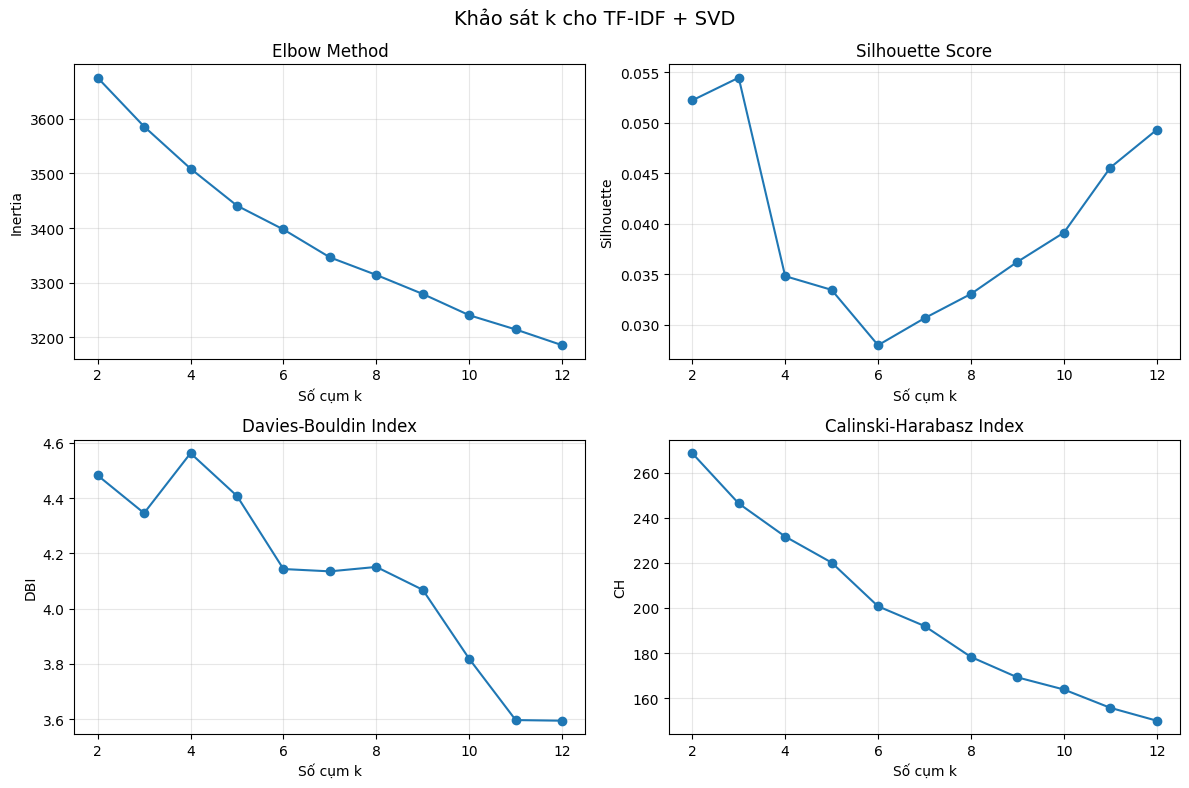

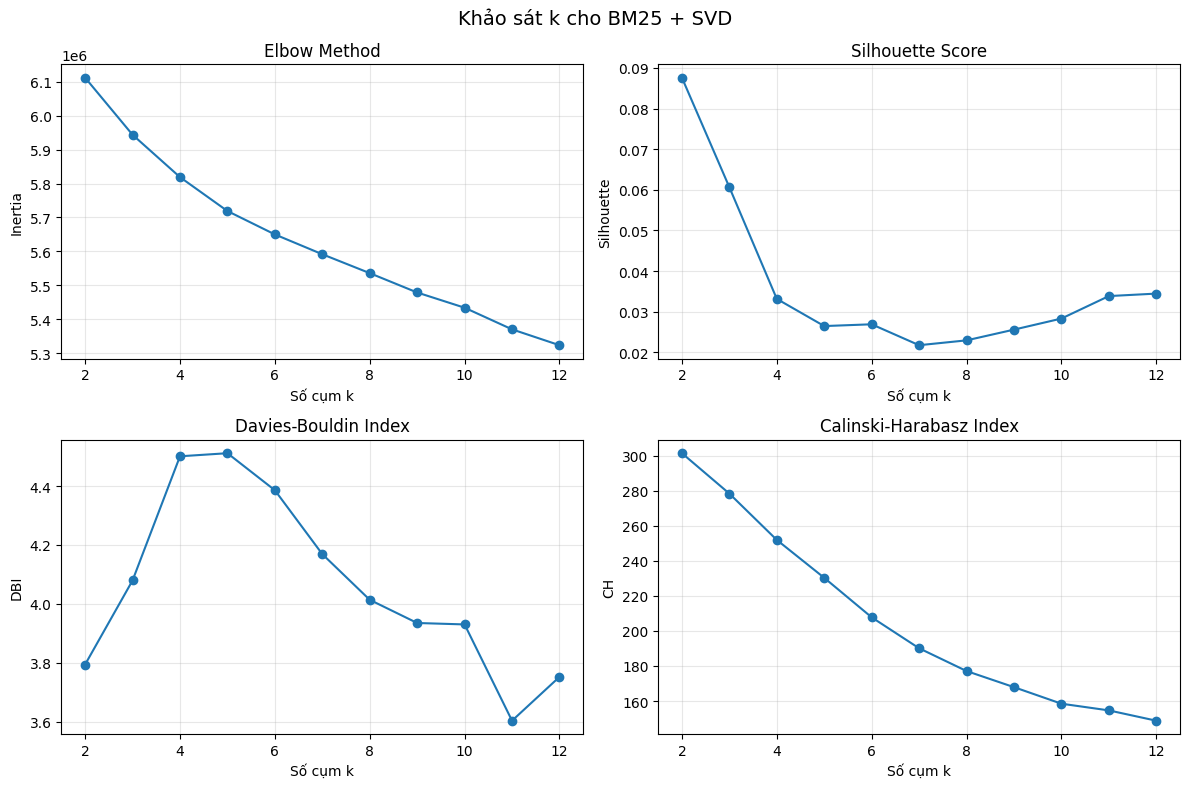

In [ ]:
# Cell 9: Vẽ 4 biểu đồ đánh giá k cho từng mô hình

def plot_k_diagnostics(result_df, title):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    axes[0, 0].plot(result_df["k"], result_df["inertia"], marker="o")
    axes[0, 0].set_title("Elbow Method")
    axes[0, 0].set_xlabel("Số cụm k")
    axes[0, 0].set_ylabel("Inertia")
    axes[0, 0].grid(alpha=0.3)

    axes[0, 1].plot(result_df["k"], result_df["silhouette"], marker="o")
    axes[0, 1].set_title("Silhouette Score")
    axes[0, 1].set_xlabel("Số cụm k")
    axes[0, 1].set_ylabel("Silhouette")
    axes[0, 1].grid(alpha=0.3)

    axes[1, 0].plot(result_df["k"], result_df["dbi"], marker="o")
    axes[1, 0].set_title("Davies-Bouldin Index")
    axes[1, 0].set_xlabel("Số cụm k")
    axes[1, 0].set_ylabel("DBI")
    axes[1, 0].grid(alpha=0.3)

    axes[1, 1].plot(result_df["k"], result_df["ch"], marker="o")
    axes[1, 1].set_title("Calinski-Harabasz Index")
    axes[1, 1].set_xlabel("Số cụm k")
    axes[1, 1].set_ylabel("CH")
    axes[1, 1].grid(alpha=0.3)

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


plot_k_diagnostics(tfidf_k_results, "Khảo sát k cho TF-IDF + SVD")
plot_k_diagnostics(bm25_k_results, "Khảo sát k cho BM25 + SVD")

### Nhận xét lựa chọn số cụm k

Kết quả khảo sát cho thấy đồ thị Elbow của cả TF-IDF + SVD và BM25 + SVD đều giảm dần khi số cụm k tăng, nhưng không xuất hiện điểm gãy thật sự rõ ràng. Điều này cho thấy việc chọn k chỉ dựa vào Elbow Method chưa đủ chắc chắn đối với dữ liệu văn bản nhiều chiều.

Với TF-IDF + SVD, Silhouette cao nhất nằm ở `k = 3` với giá trị khoảng `0.0545`. Tuy nhiên, `k = 3` quá ít so với dữ liệu gồm 6 chuyên mục báo chí. Ở `k = 6`, Silhouette giảm còn khoảng `0.0280`, nhưng đây là giá trị có ý nghĩa về mặt bài toán vì tương ứng với số chuyên mục gốc. Khi k tăng từ 6 đến 12, Silhouette có xu hướng tăng trở lại, trong đó `k = 8` tốt hơn `k = 6`.

Với BM25 + SVD, Silhouette cao nhất nằm ở `k = 2` với giá trị khoảng `0.0876`. Tuy nhiên, `k = 2` không phù hợp với mục tiêu gom cụm nhiều chuyên mục. Từ `k = 4` trở đi, Silhouette của BM25 khá thấp và nhìn chung không tốt hơn TF-IDF ở các giá trị k lớn hơn.

Chỉ số Davies-Bouldin có xu hướng giảm khi k tăng, đặc biệt ở các giá trị k lớn như 10, 11, 12. Tuy nhiên, việc chọn k quá lớn có thể làm cụm bị chia nhỏ quá mức so với cấu trúc chuyên mục ban đầu. Chỉ số Calinski-Harabasz lại giảm dần khi k tăng, cho thấy các giá trị k nhỏ có ưu thế hơn theo tiêu chí này.

Từ các kết quả trên, notebook tiếp tục đánh giá chính với `k = 6` và `k = 8`. Trong đó, `k = 6` được chọn vì phù hợp với 6 chuyên mục gốc của dữ liệu, còn `k = 8` được giữ lại để kiểm tra khả năng tách cụm chi tiết hơn. Các mô hình sau sẽ được so sánh bằng 6 chỉ số gồm Silhouette, DBI, CH, ARI, NMI và Purity.

In [ ]:
# Cell 10: Chạy KMeans chính thức cho TF-IDF và BM25
# Sau khi khảo sát k, notebook tiếp tục đánh giá chính với k = 6 và k = 8.

true_labels = df_work["category_clean"].values
K_VALUES = [6, 8]

def purity_score(y_true, y_pred):
    table = pd.crosstab(pd.Series(y_true), pd.Series(y_pred))
    return table.max(axis=0).sum() / table.values.sum()

def evaluate_clustering(X, labels, y_true):
    return {
        "Silhouette": silhouette_score(X, labels),
        "DBI": davies_bouldin_score(X, labels),
        "CH": calinski_harabasz_score(X, labels),
        "ARI": adjusted_rand_score(y_true, labels),
        "NMI": normalized_mutual_info_score(y_true, labels),
        "Purity": purity_score(y_true, labels)
    }

def run_kmeans(X, model_name, k):
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=RANDOM_STATE
    )

    labels = kmeans.fit_predict(X)
    scores = evaluate_clustering(X, labels, true_labels)

    return {
        "Model": model_name,
        "k": k,
        **scores
    }, labels

lexical_results = []

for k in K_VALUES:
    result_tfidf, labels_tfidf = run_kmeans(
        X_tfidf_svd,
        "TF-IDF + SVD + KMeans",
        k
    )
    lexical_results.append(result_tfidf)

    result_bm25, labels_bm25 = run_kmeans(
        X_bm25_svd,
        "BM25 + SVD + KMeans",
        k
    )
    lexical_results.append(result_bm25)

lexical_results_df = pd.DataFrame(lexical_results)

display(
    lexical_results_df.assign(
        Silhouette=lexical_results_df["Silhouette"].round(4),
        DBI=lexical_results_df["DBI"].round(4),
        CH=lexical_results_df["CH"].round(2),
        ARI=lexical_results_df["ARI"].round(4),
        NMI=lexical_results_df["NMI"].round(4),
        Purity=lexical_results_df["Purity"].round(4)
    )
)

lexical_results_df.to_csv(OUTPUT_LEXICAL_RESULTS, index=False, encoding="utf-8-sig")

print("Đã lưu kết quả lexical baseline tại:")
print(OUTPUT_LEXICAL_RESULTS)

,Model,k,Silhouette,DBI,CH,ARI,NMI,Purity
0,TF-IDF + SVD + KMeans,6,0.0280,4.1435,200.74,0.3775,0.5798,0.7013
1,BM25 + SVD + KMeans,6,0.0269,4.3858,207.78,0.5537,0.6058,0.7763
2,TF-IDF + SVD + KMeans,8,0.0330,4.1511,178.25,0.4886,0.6347,0.8320
3,BM25 + SVD + KMeans,8,0.0229,4.0136,177.11,0.4506,0.5324,0.7353


Đã lưu kết quả lexical baseline tại:
/content/drive/MyDrive/PROJECT/outputs/results/lexical_results.csv


### Nhận xét kết quả baseline lexical

Kết quả cho thấy các mô hình lexical baseline có Silhouette khá thấp, dao động khoảng `0.0229` đến `0.0330`. Điều này cho thấy khi chỉ sử dụng đặc trưng từ vựng như TF-IDF hoặc BM25, các cụm văn bản chưa tách biệt rõ trong không gian biểu diễn.

Với `k = 6`, BM25 cho kết quả tốt hơn TF-IDF ở các chỉ số hậu nghiệm như ARI, NMI và Purity. Cụ thể, BM25 đạt `ARI = 0.5537`, `NMI = 0.6058` và `Purity = 0.7763`, cao hơn TF-IDF ở cùng số cụm. Điều này cho thấy BM25 có khả năng ánh xạ cụm gần với nhãn chuyên mục hơn khi số cụm được đặt bằng số chuyên mục gốc.

Với `k = 8`, TF-IDF cho kết quả tốt nhất trong nhóm lexical baseline, đạt `Silhouette = 0.0330`, `ARI = 0.4886`, `NMI = 0.6347` và `Purity = 0.8320`. Trong khi đó, BM25 giảm hiệu quả ở `k = 8`, đặc biệt ở NMI và Purity.

Nhìn chung, TF-IDF + SVD + KMeans với `k = 8` được xem là baseline lexical mạnh nhất nếu xét tổng thể các chỉ số, đặc biệt là NMI và Purity. Tuy nhiên, BM25 + SVD + KMeans với `k = 6` vẫn là một cấu hình đáng chú ý vì có ARI cao nhất trong nhóm baseline.

In [ ]:
# Cell 11: Chốt baseline TF-IDF chính để so sánh với FP-Max

FINAL_K = 8

final_tfidf_kmeans = KMeans(
    n_clusters=FINAL_K,
    init="k-means++",
    n_init=10,
    random_state=RANDOM_STATE
)

tfidf_baseline_labels = final_tfidf_kmeans.fit_predict(X_tfidf_svd)

df_work["tfidf_baseline_cluster"] = tfidf_baseline_labels

tfidf_baseline_metrics = evaluate_clustering(
    X_tfidf_svd,
    tfidf_baseline_labels,
    true_labels
)

print("Baseline chính được chọn:")
print(f"Model: TF-IDF + SVD + KMeans")
print(f"k = {FINAL_K}")

print("\nMetric baseline TF-IDF:")
for metric, value in tfidf_baseline_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nPhân bố số văn bản theo cụm:")
display(
    df_work["tfidf_baseline_cluster"]
    .value_counts()
    .sort_index()
    .to_frame("n_docs")
)

Baseline chính được chọn:
Model: TF-IDF + SVD + KMeans
k = 8

Metric baseline TF-IDF:
Silhouette: 0.0330
DBI: 4.1511
CH: 178.2506
ARI: 0.4886
NMI: 0.6347
Purity: 0.8320

Phân bố số văn bản theo cụm:


,n_docs
tfidf_baseline_cluster,
0,865
1,1000
2,927
3,2483
4,312
5,641
6,1318
7,1181


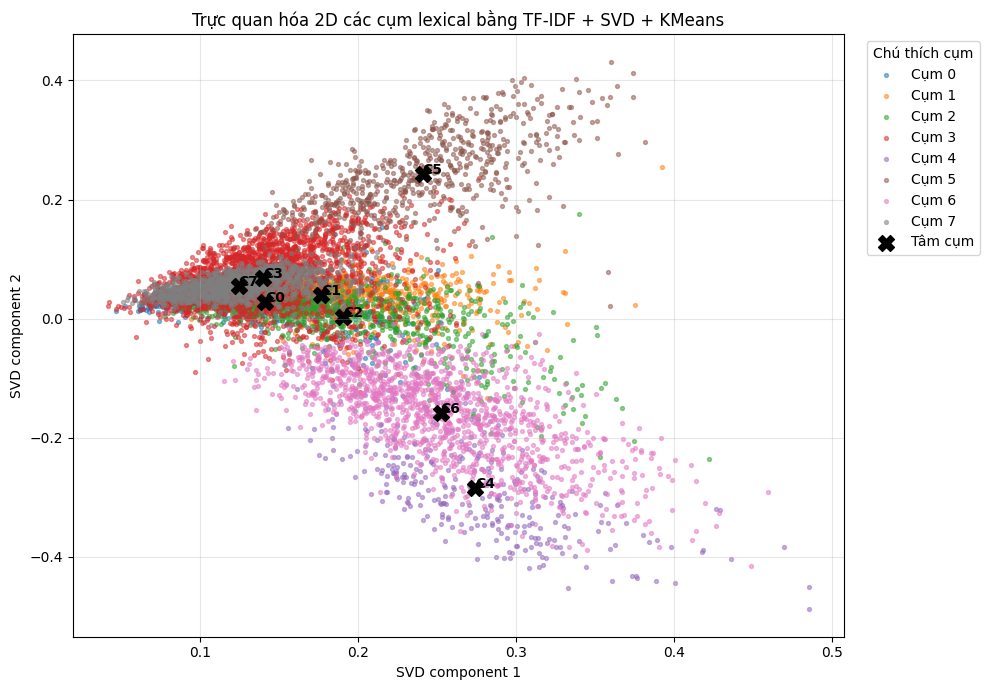

In [ ]:
# Cell 12: Trực quan hóa 2D các cụm lexical baseline
# Biểu đồ này chỉ dùng để quan sát trực quan, không dùng làm tiêu chí chính để chọn mô hình.

X_tfidf_2d = X_tfidf_svd[:, :2]

plt.figure(figsize=(10, 7))

# Vẽ từng cụm riêng để legend hiển thị rõ màu nào là cụm nào
for cluster_id in sorted(np.unique(tfidf_baseline_labels)):
    idx = tfidf_baseline_labels == cluster_id

    plt.scatter(
        X_tfidf_2d[idx, 0],
        X_tfidf_2d[idx, 1],
        s=8,
        alpha=0.5,
        label=f"Cụm {cluster_id}"
    )

# Vẽ tâm cụm theo không gian 2D
centers_2d = final_tfidf_kmeans.cluster_centers_[:, :2]

plt.scatter(
    centers_2d[:, 0],
    centers_2d[:, 1],
    marker="X",
    s=130,
    c="black",
    label="Tâm cụm"
)

for i, center in enumerate(centers_2d):
    plt.text(
        center[0],
        center[1],
        f"C{i}",
        fontsize=10,
        weight="bold"
    )

plt.title("Trực quan hóa 2D các cụm lexical bằng TF-IDF + SVD + KMeans")
plt.xlabel("SVD component 1")
plt.ylabel("SVD component 2")
plt.grid(alpha=0.3)
plt.legend(title="Chú thích cụm", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
# Cell 13: Trích xuất từ khóa nổi bật cho từng cụm lexical baseline
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

cluster_keyword_rows = []

for cluster_id in sorted(df_work["tfidf_baseline_cluster"].unique()):
    cluster_mask = (df_work["tfidf_baseline_cluster"] == cluster_id).to_numpy()

    # Lấy trung bình TF-IDF của các văn bản trong cụm
    mean_tfidf = X_tfidf[cluster_mask].mean(axis=0).A1

    top_indices = mean_tfidf.argsort()[::-1][:15]
    top_keywords = feature_names[top_indices]

    dominant_category = (
        df_work.loc[cluster_mask, "category_clean"]
        .value_counts()
        .idxmax()
    )

    cluster_size = cluster_mask.sum()

    cluster_keyword_rows.append({
        "cluster": cluster_id,
        "size": cluster_size,
        "dominant_category": dominant_category,
        "top_keywords": ", ".join(top_keywords)
    })

cluster_keywords_df = pd.DataFrame(cluster_keyword_rows)

display(cluster_keywords_df)

,cluster,size,dominant_category,top_keywords
0,0,865,suc_khoe,"thực_phẩm, ăn, có_thể, bệnh, cơ_thể, sức_khỏe,..."
1,1,1000,suc_khoe,"bệnh_viện, y_tế, bệnh, bệnh_nhân, bác_sĩ, điều..."
2,2,927,cong_nghe,"ai, công_nghệ, dữ_liệu, dùng, mạng, số, ứng_dụ..."
3,3,2483,du_lich,"xe, du_khách, du_lịch, đồng, đường, ông, biển,..."
4,4,312,giao_duc,"thi, xét, thí_sinh, tuyển, trường, đại_học, đi..."
5,5,641,du_lich,"du_lịch, khách, du_khách, quốc_tế, văn_hóa, lư..."
6,6,1318,giao_duc,"trường, học_sinh, giáo_dục, đại_học, học, đào_..."
7,7,1181,the_thao,"trận, đội, nữ, clb, cầu_thủ, hlv, giải, bóng, ..."


### Nhận xét sau khi trích xuất từ khóa nổi bật của từng cụm lexical

Bảng trên cho thấy mô hình `TF-IDF + SVD + KMeans` đã tạo được một số cụm có ý nghĩa về mặt nội dung.

Cụm `0` và cụm `1` đều liên quan đến nhóm sức khỏe, nhưng có sắc thái khác nhau. Cụm `0` nghiêng về thực phẩm, dinh dưỡng và nguy cơ sức khỏe; trong khi cụm `1` tập trung nhiều hơn vào bệnh viện, bác sĩ, bệnh nhân và hoạt động điều trị.

Cụm `2` thể hiện rõ nhóm công nghệ với các từ khóa như `ai`, `công_nghệ`, `dữ_liệu`, `mạng`, `ứng_dụng` và `hệ_thống`. Cụm `7` thể hiện rõ nhóm thể thao thông qua các từ khóa như `trận`, `đội`, `cầu_thủ`, `hlv`, `giải` và `bóng_đá`.

Đối với giáo dục, mô hình tách thành hai cụm khá rõ. Cụm `4` nghiêng về thi cử, xét tuyển và đại học; còn cụm `6` nghiêng về trường học, học sinh, giáo viên, sinh viên và hoạt động đào tạo.

Đối với du lịch, cụm `5` thể hiện khá rõ nội dung về du lịch, khách, tour, văn hóa và trải nghiệm. Tuy nhiên, cụm `3` là cụm lớn nhất và có hiện tượng pha trộn giữa du lịch, xe, giao thông và đời sống địa phương. Điều này cho thấy đặc trưng lexical vẫn còn hạn chế khi các bài báo khác chủ đề nhưng dùng chung nhiều từ vựng liên quan đến địa điểm, di chuyển, giá cả hoặc hoạt động xã hội.

Nhìn chung, baseline lexical đã tạo được các cụm có khả năng diễn giải bằng từ khóa. Tuy nhiên, việc chỉ dùng từ khóa đơn lẻ chưa thể hiện rõ quan hệ đồng xuất hiện giữa các từ. Vì vậy, phần tiếp theo sẽ sử dụng FP-Max để khai thác các pattern đồng xuất hiện và chuyển chúng thành đặc trưng nhị phân nhằm làm giàu biểu diễn TF-IDF.

In [47]:
# Cell 14: Tạo transaction nhị phân từ lexical_text cho FP-Max
# Thêm stopwords phụ để loại các token quá chung, giúp FP-Max tạo pattern dễ diễn giải hơn.

FPMAX_EXTRA_STOPWORDS = [
    # Đại từ, tên riêng, từ báo chí quá chung
    "ông", "bà", "anh", "chị", "em", "người", "nguyễn", "trần", "lê", "phạm",

    # Từ quá phổ biến, ít đặc trưng chủ đề
    "nói", "cho_biết", "theo", "về", "tại", "với", "từ", "đến",
    "của", "và", "là", "có", "được", "đang", "sẽ", "đã",
    "nhiều", "một", "các", "những", "này", "đó", "khi", "nếu",

    # Từ chung trong tin tức
    "thời_gian", "điểm", "số", "nhà", "nước", "bộ", "điều", "cách",
    "việc", "vấn_đề", "thông_tin", "hoạt_động", "chương_trình",
    "khu_vực", "địa_phương", "hiện_nay", "hiện", "qua",

    # Token còn quá chung sau lần chạy thử
    "vì", "mình", "thì", "đều", "dù", "chính", "gây", "nhằm",
    "đáng", "chú_ý", "triệu", "đồng",

    # Token bị tách chưa đẹp
    "trải", "nghiệm"
]

TRANSACTION_MIN_DF = 10
TRANSACTION_MAX_DF = 0.40
TRANSACTION_MAX_FEATURES = 3000

print("Đang tạo transaction nhị phân cho FP-Max...")
start_time = time.time()

transaction_vectorizer = CountVectorizer(
    binary=True,
    min_df=TRANSACTION_MIN_DF,
    max_df=TRANSACTION_MAX_DF,
    max_features=TRANSACTION_MAX_FEATURES,
    stop_words=FPMAX_EXTRA_STOPWORDS,
    token_pattern=r"(?u)\b[^\W\d_][\w_]{1,}\b"
)

X_transaction = transaction_vectorizer.fit_transform(df_work["lexical_text"])
transaction_items = np.array(transaction_vectorizer.get_feature_names_out())

elapsed_time = time.time() - start_time

print(f"Hoàn tất trong: {elapsed_time:.2f} giây")
print("Kích thước transaction matrix:", X_transaction.shape)
print("Số lượng item/token:", len(transaction_items))

density = X_transaction.nnz / (X_transaction.shape[0] * X_transaction.shape[1])
print("Mật độ transaction matrix:", round(density, 6))

print("\n30 item đầu tiên:")
print(transaction_items[:30])

Đang tạo transaction nhị phân cho FP-Max...
Hoàn tất trong: 6.95 giây
Kích thước transaction matrix: (8727, 3000)
Số lượng item/token: 3000
Mật độ transaction matrix: 0.042337

30 item đầu tiên:
['afc' 'ai' 'airlines' 'am_hiểu' 'an' 'an_giang' 'an_ninh' 'an_toàn'
 'an_tâm' 'app' 'apple' 'asean' 'asian' 'axit' 'ba' 'ban' 'ban_hành'
 'ban_hành_quyết_định' 'ban_ngày' 'ban_đêm' 'ban_đầu' 'bang' 'bangladesh'
 'bao' 'bao_giờ' 'bao_gồm' 'bao_nhiêu' 'bao_phủ' 'bay' 'binh']


In [48]:
# Cell 15: Chuyển transaction matrix thành danh sách transaction cho FP-Max

def sparse_binary_matrix_to_transactions(X_binary, item_names):
    transactions = []
    X_csr = X_binary.tocsr()

    for i in range(X_csr.shape[0]):
        start, end = X_csr.indptr[i], X_csr.indptr[i + 1]
        item_indices = X_csr.indices[start:end]
        transactions.append(item_names[item_indices].tolist())

    return transactions


transactions = sparse_binary_matrix_to_transactions(X_transaction, transaction_items)

transaction_lengths = pd.Series([len(t) for t in transactions])

print("Số transaction:", len(transactions))
print("Transaction đầu tiên, 30 item đầu:")
print(transactions[0][:30])

print("\nThống kê số item trong mỗi transaction:")
display(transaction_lengths.describe().to_frame("n_items_per_doc"))

Số transaction: 8727
Transaction đầu tiên, 30 item đầu:
['làn_sóng', 'máy_tính', 'ai', 'thế_giới', 'chứng_kiến', 'loạt', 'công_ty', 'liên_tiếp', 'niêm_yết', 'sàn', 'tín_hiệu', 'rõ_rệt', 'công_nghệ', 'bước_đi', 'hành_trình', 'thương_mại_hóa', 'giai_đoạn', 'sàng_lọc', 'thông_thường', 'dòng', 'tiền', 'một_vài', 'kẻ', 'thắng', 'cuộc', 'vốn', 'đầu_tư', 'khắp', 'hệ', 'sinh_thái']

Thống kê số item trong mỗi transaction:


,n_items_per_doc
count,8727.000000
mean,127.010771
std,50.097282
min,19.000000
25%,91.000000
50%,117.000000
75%,155.000000
max,479.000000


In [49]:
# Cell 16: Mã hóa danh sách transaction thành DataFrame boolean cho FP-Max
# FP-Max của mlxtend cần dữ liệu dạng bảng True/False, mỗi cột là một item.

print("Đang mã hóa transaction cho FP-Max...")
start_time = time.time()

te = TransactionEncoder()
transaction_array = te.fit(transactions).transform(transactions)

transaction_df = pd.DataFrame(
    transaction_array,
    columns=te.columns_
)

elapsed_time = time.time() - start_time

print(f"Hoàn tất trong: {elapsed_time:.2f} giây")
print("Kích thước transaction_df:", transaction_df.shape)

display(transaction_df.head(3))

Đang mã hóa transaction cho FP-Max...
Hoàn tất trong: 0.24 giây
Kích thước transaction_df: (8727, 3000)


,afc,ai,airlines,am_hiểu,an,an_giang,an_ninh,an_toàn,an_tâm,app,...,ổn,ổn_định,ủng_hộ,ủy,ủy_ban,ức_chế,ứng_dụng,ứng_phó,ứng_viên,ứng_xử
0,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,False,True,False,False,True,True,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [50]:
# Cell 17: Khảo sát min_support cho FP-Max
# Chỉ khảo sát các ngưỡng an toàn để tránh FP-Max chạy quá lâu.

SUPPORT_VALUES = [0.12, 0.10, 0.08, 0.06, 0.05]

PATTERN_MIN_LEN = 2
PATTERN_MAX_LEN = 4

fpmax_survey_rows = []

for support in SUPPORT_VALUES:
    print(f"Đang chạy FP-Max với min_support = {support}...")
    start_time = time.time()

    patterns = fpmax(
        transaction_df,
        min_support=support,
        use_colnames=True,
        max_len=PATTERN_MAX_LEN
    )

    elapsed_time = time.time() - start_time

    if len(patterns) > 0:
        patterns["pattern_length"] = patterns["itemsets"].apply(len)

        patterns_filtered = patterns[
            (patterns["pattern_length"] >= PATTERN_MIN_LEN) &
            (patterns["pattern_length"] <= PATTERN_MAX_LEN)
        ].copy()

        min_pattern_support = patterns_filtered["support"].min() if len(patterns_filtered) > 0 else np.nan
        max_pattern_support = patterns_filtered["support"].max() if len(patterns_filtered) > 0 else np.nan
    else:
        patterns_filtered = pd.DataFrame()
        min_pattern_support = np.nan
        max_pattern_support = np.nan

    fpmax_survey_rows.append({
        "min_support": support,
        "n_patterns_raw": len(patterns),
        "n_patterns_filtered": len(patterns_filtered),
        "min_pattern_support": min_pattern_support,
        "max_pattern_support": max_pattern_support,
        "elapsed_seconds": elapsed_time
    })

fpmax_survey_df = pd.DataFrame(fpmax_survey_rows)

display(
    fpmax_survey_df.assign(
        min_pattern_support=fpmax_survey_df["min_pattern_support"].round(4),
        max_pattern_support=fpmax_survey_df["max_pattern_support"].round(4),
        elapsed_seconds=fpmax_survey_df["elapsed_seconds"].round(2)
    )
)

Đang chạy FP-Max với min_support = 0.12...
Đang chạy FP-Max với min_support = 0.1...
Đang chạy FP-Max với min_support = 0.08...
Đang chạy FP-Max với min_support = 0.06...
Đang chạy FP-Max với min_support = 0.05...


,min_support,n_patterns_raw,n_patterns_filtered,min_pattern_support,max_pattern_support,elapsed_seconds
0,0.12,239,7,0.1205,0.1484,4.60
1,0.10,311,16,0.1000,0.1484,11.71
2,0.08,490,113,0.0802,0.1134,19.54
3,0.06,1343,899,0.0600,0.1134,42.37
4,0.05,2900,2420,0.0501,0.1070,97.61


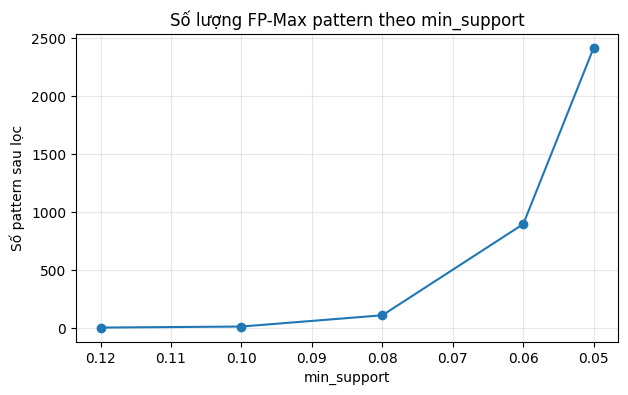

In [51]:
# Cell 18: Vẽ biểu đồ số lượng pattern theo min_support

plt.figure(figsize=(7, 4))

plt.plot(
    fpmax_survey_df["min_support"],
    fpmax_survey_df["n_patterns_filtered"],
    marker="o"
)

plt.gca().invert_xaxis()
plt.xlabel("min_support")
plt.ylabel("Số pattern sau lọc")
plt.title("Số lượng FP-Max pattern theo min_support")
plt.grid(alpha=0.3)
plt.show()

### Nhận xét khảo sát min_support sau khi lọc stopwords phụ

Sau khi bổ sung stopwords phụ, số lượng FP-Max pattern giảm rõ rệt so với lần chạy ban đầu. Điều này cho thấy việc loại bỏ các token quá chung giúp giảm nhiễu và kiểm soát tốt hơn số lượng pattern sinh ra.

Kết quả khảo sát cho thấy `min_support = 0.12` và `0.10` tạo ra quá ít pattern sau lọc, lần lượt là 7 và 16 pattern. Số lượng này chưa đủ để làm giàu đặc trưng TF-IDF. Ngược lại, `min_support = 0.06` và `0.05` tạo ra lần lượt 899 và 2420 pattern, làm tăng số chiều quá nhiều và có nguy cơ đưa thêm nhiễu vào mô hình.

Vì vậy, notebook chọn `min_support = 0.08` cho bước FP-Max chính thức. Cấu hình này tạo ra 113 pattern sau lọc, nằm trong khoảng mục tiêu khoảng 100–300 pattern, phù hợp để bổ sung đặc trưng đồng xuất hiện từ vựng cho mô hình lexical baseline.

In [52]:
# Cell 19: Chạy FP-Max chính thức với min_support đã chọn

FPMAX_MIN_SUPPORT = 0.08
PATTERN_MIN_LEN = 2
PATTERN_MAX_LEN = 4

print("Đang chạy FP-Max chính thức...")
start_time = time.time()

fpmax_patterns = fpmax(
    transaction_df,
    min_support=FPMAX_MIN_SUPPORT,
    use_colnames=True,
    max_len=PATTERN_MAX_LEN
)

elapsed_time = time.time() - start_time

fpmax_patterns["pattern_length"] = fpmax_patterns["itemsets"].apply(len)

fpmax_patterns_filtered = fpmax_patterns[
    (fpmax_patterns["pattern_length"] >= PATTERN_MIN_LEN) &
    (fpmax_patterns["pattern_length"] <= PATTERN_MAX_LEN)
].copy()

fpmax_patterns_filtered = fpmax_patterns_filtered.sort_values(
    by=["support", "pattern_length"],
    ascending=[False, False]
).reset_index(drop=True)

fpmax_patterns_filtered["pattern"] = fpmax_patterns_filtered["itemsets"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

print(f"Hoàn tất trong: {elapsed_time:.2f} giây")
print("Số pattern ban đầu:", len(fpmax_patterns))
print("Số pattern sau lọc:", len(fpmax_patterns_filtered))

display(fpmax_patterns_filtered[["support", "pattern_length", "pattern"]].head(20))

Đang chạy FP-Max chính thức...
Hoàn tất trong: 19.62 giây
Số pattern ban đầu: 490
Số pattern sau lọc: 113


,support,pattern_length,pattern
0,0.113441,2,"quốc_gia, quốc_tế"
1,0.107024,2,"mạng, xã_hội"
2,0.106337,2,"công_nghệ, hệ_thống"
3,0.104962,2,"bác_sĩ, bệnh_viện"
4,0.103243,3,"giáo_dục, trường, đào_tạo"
5,0.100951,2,"bệnh, y_tế"
6,0.100034,2,"cơ_sở, trường"
7,0.099920,2,"du_lịch, văn_hóa"
8,0.099805,2,"cơ_sở, y_tế"
9,0.098545,2,"bệnh_viện, điều_trị"


In [54]:
# Cell 20: Lưu danh sách FP-Max pattern chính thức

fpmax_patterns_filtered.to_csv(
    OUTPUT_FPMAX_PATTERNS,
    index=False,
    encoding="utf-8-sig"
)

print("Đã lưu FP-Max patterns tại:")
print(OUTPUT_FPMAX_PATTERNS)

Đã lưu FP-Max patterns tại:
/content/drive/MyDrive/PROJECT/outputs/patterns/fpmax_patterns_lexical.csv


In [55]:
# Cell 21: Chuyển FP-Max pattern thành feature nhị phân cho từng văn bản
# Nếu một văn bản chứa đầy đủ các item trong pattern thì feature đó nhận giá trị 1, ngược lại là 0.

selected_patterns = fpmax_patterns_filtered["itemsets"].tolist()
selected_pattern_names = fpmax_patterns_filtered["pattern"].tolist()

print("Số pattern được dùng làm feature:", len(selected_patterns))

# Chuyển mỗi transaction thành set để kiểm tra nhanh hơn
transaction_sets = [set(t) for t in transactions]

fpmax_feature_data = []

for doc_items in transaction_sets:
    row = []

    for pattern_items in selected_patterns:
        # Feature = 1 nếu toàn bộ item trong pattern xuất hiện trong văn bản
        row.append(int(pattern_items.issubset(doc_items)))

    fpmax_feature_data.append(row)

X_fpmax_features = csr_matrix(fpmax_feature_data)

fpmax_feature_df = pd.DataFrame(
    X_fpmax_features.toarray(),
    columns=[f"fpmax_{i}" for i in range(len(selected_patterns))]
)

print("Kích thước ma trận FP-Max feature:", X_fpmax_features.shape)

density = X_fpmax_features.nnz / (X_fpmax_features.shape[0] * X_fpmax_features.shape[1])
print("Mật độ FP-Max feature:", round(density, 6))

display(fpmax_feature_df.head())

Số pattern được dùng làm feature: 113
Kích thước ma trận FP-Max feature: (8727, 113)
Mật độ FP-Max feature: 0.088347


,fpmax_0,fpmax_1,fpmax_2,fpmax_3,fpmax_4,fpmax_5,fpmax_6,fpmax_7,fpmax_8,fpmax_9,...,fpmax_103,fpmax_104,fpmax_105,fpmax_106,fpmax_107,fpmax_108,fpmax_109,fpmax_110,fpmax_111,fpmax_112
0,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


### Nhận xét tạo FP-Max feature

Kết quả cho thấy 113 FP-Max pattern đã được chuyển thành ma trận đặc trưng nhị phân có kích thước `(8727, 113)`. Mỗi dòng tương ứng với một văn bản, mỗi cột tương ứng với một pattern FP-Max. Giá trị `1` cho biết văn bản chứa đầy đủ các item trong pattern, còn `0` cho biết không chứa đầy đủ pattern đó.

Mật độ của ma trận FP-Max feature là `0.0883`, cho thấy các pattern không xuất hiện quá dày đặc trong toàn bộ dữ liệu. Điều này phù hợp với vai trò của FP-Max: bổ sung tín hiệu đồng xuất hiện từ vựng có chọn lọc cho biểu diễn TF-IDF.


In [56]:
# Cell 22: Lưu ma trận FP-Max feature và thông tin pattern

save_npz(OUTPUT_FPMAX_FEATURES, X_fpmax_features)

fpmax_feature_info = fpmax_patterns_filtered[[
    "support",
    "pattern_length",
    "pattern"
]].copy()

fpmax_feature_info["feature_name"] = [
    f"fpmax_{i}" for i in range(len(fpmax_feature_info))
]

fpmax_feature_info = fpmax_feature_info[[
    "feature_name",
    "support",
    "pattern_length",
    "pattern"
]]

OUTPUT_FPMAX_FEATURE_INFO = FEATURES_DIR / "fpmax_feature_info.csv"

fpmax_feature_info.to_csv(
    OUTPUT_FPMAX_FEATURE_INFO,
    index=False,
    encoding="utf-8-sig"
)

print("Đã lưu ma trận FP-Max feature tại:")
print(OUTPUT_FPMAX_FEATURES)

print("\nĐã lưu thông tin FP-Max feature tại:")
print(OUTPUT_FPMAX_FEATURE_INFO)


Đã lưu ma trận FP-Max feature tại:
/content/drive/MyDrive/PROJECT/outputs/features/fpmax_binary_features.npz

Đã lưu thông tin FP-Max feature tại:
/content/drive/MyDrive/PROJECT/outputs/features/fpmax_feature_info.csv


In [57]:
# Cell 23: Ghép TF-IDF với FP-Max feature để tạo đặc trưng enriched
# FP-Max feature là tín hiệu bổ sung, nên dùng hệ số alpha để kiểm soát mức ảnh hưởng.

ALPHA_VALUES = [0.1, 0.2, 0.5]

# Chuẩn hóa trước khi ghép để tránh FP-Max feature ảnh hưởng quá mạnh
X_tfidf_norm = normalize(X_tfidf, norm="l2")
X_fpmax_norm = normalize(X_fpmax_features, norm="l2")

X_enriched_dict = {}

for alpha in ALPHA_VALUES:
    X_enriched = hstack([
        X_tfidf_norm,
        alpha * X_fpmax_norm
    ]).tocsr()

    X_enriched_dict[alpha] = X_enriched

    density = X_enriched.nnz / (X_enriched.shape[0] * X_enriched.shape[1])

    print(f"Alpha = {alpha}")
    print("Kích thước ma trận enriched:", X_enriched.shape)
    print("Mật độ:", round(density, 6))
    print("-" * 50)

Alpha = 0.1
Kích thước ma trận enriched: (8727, 10113)
Mật độ: 0.016444
--------------------------------------------------
Alpha = 0.2
Kích thước ma trận enriched: (8727, 10113)
Mật độ: 0.016444
--------------------------------------------------
Alpha = 0.5
Kích thước ma trận enriched: (8727, 10113)
Mật độ: 0.016444
--------------------------------------------------


In [58]:
# Cell 24: Giảm chiều TF-IDF + FP-Max bằng TruncatedSVD
# Sau khi ghép thêm FP-Max, ma trận enriched có hơn 10000 chiều nên cần giảm chiều trước khi KMeans.

ENRICHED_SVD_COMPONENTS = 300

X_enriched_svd_dict = {}
svd_enriched_dict = {}

for alpha, X_enriched in X_enriched_dict.items():
    print(f"Đang giảm chiều enriched features với alpha = {alpha}...")
    start_time = time.time()

    svd_enriched = TruncatedSVD(
        n_components=ENRICHED_SVD_COMPONENTS,
        random_state=RANDOM_STATE
    )

    X_enriched_svd = svd_enriched.fit_transform(X_enriched)

    elapsed_time = time.time() - start_time

    X_enriched_svd_dict[alpha] = X_enriched_svd
    svd_enriched_dict[alpha] = svd_enriched

    print(f"Hoàn tất trong: {elapsed_time:.2f} giây")
    print("Shape:", X_enriched_svd.shape)
    print("Explained variance:", round(svd_enriched.explained_variance_ratio_.sum(), 4))
    print("-" * 50)

Đang giảm chiều enriched features với alpha = 0.1...
Hoàn tất trong: 18.35 giây
Shape: (8727, 300)
Explained variance: 0.4477
--------------------------------------------------
Đang giảm chiều enriched features với alpha = 0.2...
Hoàn tất trong: 5.65 giây
Shape: (8727, 300)
Explained variance: 0.4475
--------------------------------------------------
Đang giảm chiều enriched features với alpha = 0.5...
Hoàn tất trong: 8.63 giây
Shape: (8727, 300)
Explained variance: 0.4996
--------------------------------------------------


In [59]:
# Cell 25: Chạy KMeans trên đặc trưng TF-IDF + FP-Max với từng alpha
# Mục tiêu: so sánh mô hình enriched với baseline TF-IDF ban đầu.

ENRICHED_K = 8

fpmax_enriched_results = []
fpmax_enriched_labels_dict = {}

for alpha, X_enriched_svd in X_enriched_svd_dict.items():
    print(f"Đang chạy KMeans cho TF-IDF + FP-Max với alpha = {alpha}...")

    kmeans_enriched = KMeans(
        n_clusters=ENRICHED_K,
        init="k-means++",
        n_init=10,
        random_state=RANDOM_STATE
    )

    labels_enriched = kmeans_enriched.fit_predict(X_enriched_svd)
    fpmax_enriched_labels_dict[alpha] = labels_enriched

    scores = evaluate_clustering(
        X_enriched_svd,
        labels_enriched,
        true_labels
    )

    fpmax_enriched_results.append({
        "Model": "TF-IDF + FP-Max + SVD + KMeans",
        "alpha": alpha,
        "k": ENRICHED_K,
        **scores
    })

fpmax_enriched_results_df = pd.DataFrame(fpmax_enriched_results)

display(
    fpmax_enriched_results_df.assign(
        Silhouette=fpmax_enriched_results_df["Silhouette"].round(4),
        DBI=fpmax_enriched_results_df["DBI"].round(4),
        CH=fpmax_enriched_results_df["CH"].round(2),
        ARI=fpmax_enriched_results_df["ARI"].round(4),
        NMI=fpmax_enriched_results_df["NMI"].round(4),
        Purity=fpmax_enriched_results_df["Purity"].round(4)
    )
)

Đang chạy KMeans cho TF-IDF + FP-Max với alpha = 0.1...
Đang chạy KMeans cho TF-IDF + FP-Max với alpha = 0.2...
Đang chạy KMeans cho TF-IDF + FP-Max với alpha = 0.5...


,Model,alpha,k,Silhouette,DBI,CH,ARI,NMI,Purity
0,TF-IDF + FP-Max + SVD + KMeans,0.1,8,0.0355,3.9296,179.52,0.3719,0.5856,0.7332
1,TF-IDF + FP-Max + SVD + KMeans,0.2,8,0.0375,3.8829,187.96,0.4344,0.6143,0.7695
2,TF-IDF + FP-Max + SVD + KMeans,0.5,8,0.0442,4.0747,206.46,0.4103,0.5760,0.7817


### Nhận xét lựa chọn alpha cho mô hình TF-IDF + FP-Max

Kết quả cho thấy khi tăng alpha, Silhouette và CH có xu hướng tăng, chứng tỏ FP-Max có thể bổ sung thêm tín hiệu giúp cấu trúc cụm tách rõ hơn theo một số chỉ số nội bộ. Trong đó, `alpha = 0.5` đạt Silhouette và CH cao nhất, nhưng DBI lại tăng trở lại và NMI thấp hơn so với `alpha = 0.2`.

Vì vậy, notebook chọn `alpha = 0.2` làm cấu hình  `TF-IDF + FP-Max chính thức`. Đây là mức cân bằng nhất vì vừa cải thiện Silhouette, DBI và CH so với baseline TF-IDF, vừa không để FP-Max ảnh hưởng quá mạnh như `alpha = 0.5`.



In [61]:
# Cell 26: So sánh baseline TF-IDF với cấu hình TF-IDF + FP-Max tốt nhất

BEST_ALPHA = 0.2

baseline_compare_row = lexical_results_df[
    (lexical_results_df["Model"] == "TF-IDF + SVD + KMeans") &
    (lexical_results_df["k"] == 8)
].copy()

baseline_compare_row["alpha"] = 0.0
baseline_compare_row["Model"] = "Baseline TF-IDF"

best_fpmax_row = fpmax_enriched_results_df[
    fpmax_enriched_results_df["alpha"] == BEST_ALPHA
].copy()

best_fpmax_row["Model"] = "TF-IDF + FP-Max"

comparison_df = pd.concat(
    [
        baseline_compare_row[["Model", "alpha", "k", "Silhouette", "DBI", "CH", "ARI", "NMI", "Purity"]],
        best_fpmax_row[["Model", "alpha", "k", "Silhouette", "DBI", "CH", "ARI", "NMI", "Purity"]]
    ],
    ignore_index=True
)

display(
    comparison_df.assign(
        Silhouette=comparison_df["Silhouette"].round(4),
        DBI=comparison_df["DBI"].round(4),
        CH=comparison_df["CH"].round(2),
        ARI=comparison_df["ARI"].round(4),
        NMI=comparison_df["NMI"].round(4),
        Purity=comparison_df["Purity"].round(4)
    )
)

comparison_df.to_csv(
    OUTPUT_LEXICAL_FPMAX_RESULTS,
    index=False,
    encoding="utf-8-sig"
)

print("Đã lưu kết quả so sánh baseline và FP-Max tại:")
print(OUTPUT_LEXICAL_FPMAX_RESULTS)

,Model,alpha,k,Silhouette,DBI,CH,ARI,NMI,Purity
0,Baseline TF-IDF,0.0,8,0.0330,4.1511,178.25,0.4886,0.6347,0.8320
1,TF-IDF + FP-Max,0.2,8,0.0375,3.8829,187.96,0.4344,0.6143,0.7695


Đã lưu kết quả so sánh baseline và FP-Max tại:
/content/drive/MyDrive/PROJECT/outputs/results/lexical_fpmax_results.csv


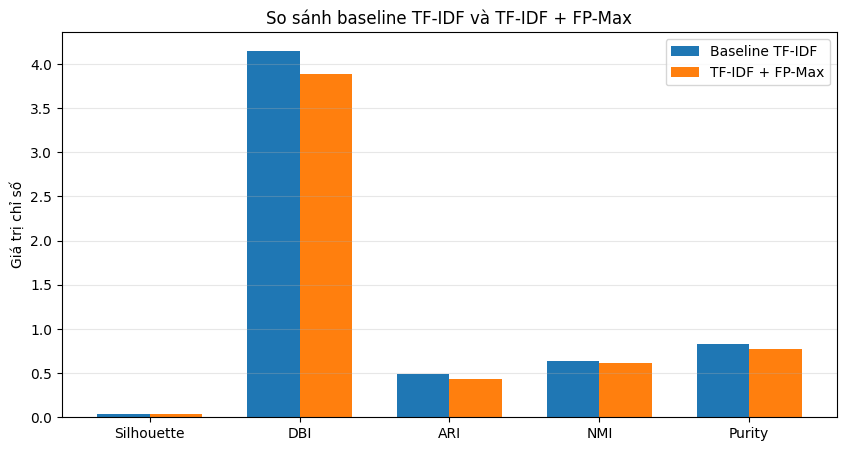

In [62]:
# Cell 27: Trực quan hóa so sánh baseline TF-IDF và TF-IDF + FP-Max

comparison_plot_df = comparison_df.copy()

metrics_to_plot = ["Silhouette", "DBI", "ARI", "NMI", "Purity"]

comparison_plot_df_melted = comparison_plot_df.melt(
    id_vars=["Model"],
    value_vars=metrics_to_plot,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 5))

x = np.arange(len(metrics_to_plot))
width = 0.35

baseline_scores = comparison_df.loc[
    comparison_df["Model"] == "Baseline TF-IDF",
    metrics_to_plot
].values.flatten()

fpmax_scores = comparison_df.loc[
    comparison_df["Model"] == "TF-IDF + FP-Max",
    metrics_to_plot
].values.flatten()

plt.bar(x - width/2, baseline_scores, width, label="Baseline TF-IDF")
plt.bar(x + width/2, fpmax_scores, width, label="TF-IDF + FP-Max")

plt.xticks(x, metrics_to_plot)
plt.ylabel("Giá trị chỉ số")
plt.title("So sánh baseline TF-IDF và TF-IDF + FP-Max")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

### Nhận xét biểu đồ so sánh baseline và FP-Max

Kết quả cho thấy FP-Max giúp cải thiện một số chỉ số nội bộ như Silhouette và DBI, cho thấy cấu trúc cụm có xu hướng tách tốt hơn sau khi bổ sung đặc trưng đồng xuất hiện. Tuy nhiên, các chỉ số hậu nghiệm như ARI, NMI và Purity giảm so với baseline TF-IDF, nghĩa là mô hình enriched chưa khớp với nhãn chuyên mục gốc tốt hơn baseline.

Vì vậy, FP-Max trong notebook này được xem là đặc trưng bổ sung giúp cải thiện một phần cấu trúc cụm và tăng khả năng diễn giải, thay vì khẳng định cải thiện toàn diện tất cả chỉ số.

In [71]:
# Cell 28: Khai thác FP-Max pattern nổi bật theo từng cụm
# Mục tiêu: tạo bảng chi tiết các pattern đặc trưng cho từng cụm để phục vụ phân tích và lưu kết quả.

BEST_ALPHA = 0.2
best_fpmax_labels = fpmax_enriched_labels_dict[BEST_ALPHA]

# Ma trận FP-Max chỉ có 113 cột nên có thể chuyển sang dense để tính toán
X_fpmax_dense = X_fpmax_features.toarray()

pattern_profile_rows = []

for cluster_id in sorted(np.unique(best_fpmax_labels)):
    cluster_mask = best_fpmax_labels == cluster_id
    cluster_size = cluster_mask.sum()

    # Tỷ lệ xuất hiện của từng pattern trong cụm
    cluster_pattern_rate = X_fpmax_dense[cluster_mask].mean(axis=0)

    # Tỷ lệ xuất hiện của từng pattern trên toàn bộ dữ liệu
    global_pattern_rate = X_fpmax_dense.mean(axis=0)

    # Lift cho biết pattern xuất hiện trong cụm nhiều hơn trung bình toàn bộ dữ liệu bao nhiêu lần
    lift = cluster_pattern_rate / (global_pattern_rate + 1e-9)

    # Ưu tiên pattern vừa xuất hiện nhiều trong cụm, vừa đặc trưng cho cụm
    score = cluster_pattern_rate * lift

    top_pattern_indices = score.argsort()[::-1][:8]

    majority_category = (
        pd.Series(true_labels[cluster_mask])
        .value_counts()
        .idxmax()
    )

    for rank, pattern_idx in enumerate(top_pattern_indices, start=1):
        pattern_profile_rows.append({
            "cluster": cluster_id,
            "cluster_size": cluster_size,
            "majority_category_in_cluster": majority_category,
            "rank": rank,
            "feature_name": f"fpmax_{pattern_idx}",
            "pattern": fpmax_feature_info.loc[pattern_idx, "pattern"],
            "support": fpmax_feature_info.loc[pattern_idx, "support"],
            "pattern_length": fpmax_feature_info.loc[pattern_idx, "pattern_length"],
            "cluster_pattern_rate": cluster_pattern_rate[pattern_idx],
            "global_pattern_rate": global_pattern_rate[pattern_idx],
            "lift": lift[pattern_idx]
        })

cluster_pattern_profile_df = pd.DataFrame(pattern_profile_rows)

print("Đã tạo bảng chi tiết FP-Max pattern theo cụm.")
print("Kích thước bảng:", cluster_pattern_profile_df.shape)

display(
    cluster_pattern_profile_df.head(10).assign(
        support=cluster_pattern_profile_df.head(10)["support"].round(4),
        cluster_pattern_rate=cluster_pattern_profile_df.head(10)["cluster_pattern_rate"].round(4),
        global_pattern_rate=cluster_pattern_profile_df.head(10)["global_pattern_rate"].round(4),
        lift=cluster_pattern_profile_df.head(10)["lift"].round(2)
    )
)

Đã tạo bảng chi tiết FP-Max pattern theo cụm.
Kích thước bảng: (64, 11)


,cluster,cluster_size,majority_category_in_cluster,rank,feature_name,pattern,support,pattern_length,cluster_pattern_rate,global_pattern_rate,lift
0,0,466,suc_khoe,1,fpmax_5,"bệnh, y_tế",0.1010,2,0.8455,0.1010,8.38
1,0,466,suc_khoe,2,fpmax_8,"cơ_sở, y_tế",0.0998,2,0.8133,0.0998,8.15
2,0,466,suc_khoe,3,fpmax_81,"bệnh, khám",0.0834,2,0.7275,0.0834,8.72
3,0,466,suc_khoe,4,fpmax_14,"bệnh_viện, y_tế",0.0971,2,0.7060,0.0971,7.27
4,0,466,suc_khoe,5,fpmax_48,"y_tế, điều_trị",0.0880,2,0.6052,0.0880,6.88
5,0,466,suc_khoe,6,fpmax_28,"sức_khỏe, y_tế",0.0912,2,0.6052,0.0912,6.63
6,0,466,suc_khoe,7,fpmax_21,"bệnh, bệnh_viện",0.0941,2,0.6094,0.0941,6.48
7,0,466,suc_khoe,8,fpmax_52,"cơ_sở, dân",0.0873,2,0.5579,0.0873,6.39
8,1,1181,suc_khoe,1,fpmax_3,"bác_sĩ, bệnh_viện",0.1050,2,0.5673,0.1050,5.40
9,1,1181,suc_khoe,2,fpmax_49,"bác_sĩ, điều_trị",0.0880,2,0.4945,0.0880,5.62


In [73]:
# Cell 29: Tóm tắt FP-Max pattern nổi bật theo từng cụm
# Chỉ lấy các pattern tiêu biểu có lift đủ cao để diễn giải cụm.

MIN_LIFT = 2.0
TOP_N_PATTERNS = 3

cluster_pattern_summary_rows = []

for cluster_id in sorted(cluster_pattern_profile_df["cluster"].unique()):
    cluster_rows = cluster_pattern_profile_df[
        cluster_pattern_profile_df["cluster"] == cluster_id
    ].copy()

    cluster_size = cluster_rows["cluster_size"].iloc[0]
    majority_category = cluster_rows["majority_category_in_cluster"].iloc[0]

    # Chỉ giữ pattern đủ đặc trưng
    strong_patterns = cluster_rows[
        cluster_rows["lift"] >= MIN_LIFT
    ].sort_values(
        by=["lift", "cluster_pattern_rate"],
        ascending=False
    ).head(TOP_N_PATTERNS)

    if len(strong_patterns) > 0:
        top_patterns = "; ".join(strong_patterns["pattern"].tolist())
        top_lifts = "; ".join(strong_patterns["lift"].round(2).astype(str).tolist())
        interpretability_note = "Có pattern đặc trưng"
    else:
        top_patterns = "Không có pattern đặc trưng rõ"
        top_lifts = ""
        interpretability_note = "Cụm pha trộn hoặc pattern yếu"

    cluster_pattern_summary_rows.append({
        "cluster": cluster_id,
        "cluster_size": cluster_size,
        "majority_category_in_cluster": majority_category,
        "top_fpmax_patterns": top_patterns,
        "top_lift_values": top_lifts,
        "interpretability_note": interpretability_note
    })

cluster_pattern_summary_df = pd.DataFrame(cluster_pattern_summary_rows)

display(cluster_pattern_summary_df)

,cluster,cluster_size,majority_category_in_cluster,top_fpmax_patterns,top_lift_values,interpretability_note
0,0,466,suc_khoe,"bệnh, khám; bệnh, y_tế; cơ_sở, y_tế",8.72; 8.38; 8.15,Có pattern đặc trưng
1,1,1181,suc_khoe,"bác_sĩ, điều_trị; bệnh_nhân, bệnh_viện; bác_sĩ...",5.62; 5.42; 5.4,Có pattern đặc trưng
2,2,801,du_lich,"du_khách, du_lịch, khách; du_lịch, quốc_tế; du...",7.48; 7.25; 6.45,Có pattern đặc trưng
3,3,1373,giao_duc,"nhà_trường, trường; giáo_dục, học, trường; học...",5.01; 4.97; 4.9,Có pattern đặc trưng
4,4,466,xe,"hệ_thống, một_số; hệ_thống, khả_năng; công_ngh...",2.58; 2.49; 2.04,Có pattern đặc trưng
5,5,1188,the_thao,Không có pattern đặc trưng rõ,,Cụm pha trộn hoặc pattern yếu
6,6,309,giao_duc,"trường, đào_tạo, đại_học; giáo_dục, trường, đà...",6.69; 5.83; 5.66,Có pattern đặc trưng
7,7,2943,du_lich,Không có pattern đặc trưng rõ,,Cụm pha trộn hoặc pattern yếu


### Nhận xét khai thác mẫu FP-Max theo cụm

Bảng trên tóm tắt các FP-Max pattern nổi bật theo từng cụm của mô hình `TF-IDF + FP-Max`. Để tránh trình bày quá nhiều mẫu và tránh diễn giải quá mức, notebook chỉ giữ tối đa 3 pattern có `lift >= 2` cho mỗi cụm.

Kết quả cho thấy một số cụm có pattern đặc trưng khá rõ. Các cụm sức khỏe có các pattern như `bệnh, y_tế`, `cơ_sở, y_tế`, `bác_sĩ, bệnh_viện` và `bệnh_viện, điều_trị`. Các cụm giáo dục có các pattern như `giáo_dục, trường, đào_tạo`, `giáo_dục, học, trường` và `trường, đào_tạo, đại_học`. Cụm du lịch cũng có các pattern liên quan đến `du_khách`, `du_lịch`, `khách` và `quốc_tế`.

Tuy nhiên, không phải cụm nào cũng có pattern đặc trưng rõ. Một số cụm như cụm `5` và cụm `7` không có pattern đủ mạnh sau khi lọc theo lift, cho thấy các cụm này còn pha trộn nội dung hoặc chưa có mẫu đồng xuất hiện thật sự nổi bật.

Như vậy, FP-Max có giá trị trong việc bổ sung khả năng diễn giải cho các cụm có mẫu đồng xuất hiện rõ, đồng thời giúp phát hiện những cụm còn khó diễn giải. Kết quả này phù hợp với vai trò của FP-Max trong notebook: vừa làm giàu đặc trưng, vừa hỗ trợ khai thác mẫu cho phân tích cụm.

In [74]:
# Cell 30: Lưu kết quả khai thác mẫu FP-Max theo cụm
# Lưu bảng chi tiết và bảng tóm tắt để dùng lại ở Notebook 6 hoặc phần báo cáo.

OUTPUT_CLUSTER_PATTERN_PROFILE = PATTERNS_DIR / "cluster_fpmax_pattern_profile.csv"
OUTPUT_CLUSTER_PATTERN_SUMMARY = PATTERNS_DIR / "cluster_fpmax_pattern_summary.csv"

cluster_pattern_profile_df.to_csv(
    OUTPUT_CLUSTER_PATTERN_PROFILE,
    index=False,
    encoding="utf-8-sig"
)

cluster_pattern_summary_df.to_csv(
    OUTPUT_CLUSTER_PATTERN_SUMMARY,
    index=False,
    encoding="utf-8-sig"
)

print("Đã lưu bảng pattern chi tiết tại:")
print(OUTPUT_CLUSTER_PATTERN_PROFILE)

print("\nĐã lưu bảng pattern tóm tắt tại:")
print(OUTPUT_CLUSTER_PATTERN_SUMMARY)

Đã lưu bảng pattern chi tiết tại:
/content/drive/MyDrive/PROJECT/outputs/patterns/cluster_fpmax_pattern_profile.csv

Đã lưu bảng pattern tóm tắt tại:
/content/drive/MyDrive/PROJECT/outputs/patterns/cluster_fpmax_pattern_summary.csv
